# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Cristian Jara
- Nombre de alumno 2: Felipe Fierro

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/cristianjaram/MDS7202-labs/tree/main/labs)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. La principal diferencia  entre data de entrenamiento y validación es que la de entrenamiento se uda para ajustar parámetros de un modelo (aprender patrones a partir de data de ejemplo) y validación se usa para evaluar el rendimiento de este modelo entrenado con data que no vio en el entrenamiento. Permite ajustar hiperparámetros, comparar modelos entre sí y evitar overfitting.
2. En clasificación supervisada necesitamos etiquetas (ej. “seleccionado/no seleccionado”).
En no supervisada no hay etiquetas por lo que el desafío es que no se puede medir directamente si las predicciones son correctas. Hay que recurrir a técnicas como clustering, métricas internas (silhouette, cohesión, separación), o eventualmente generar etiquetas manualmente para evaluar.
3. Es una tabla que compara las predicciones del modelo con las etiquetas reales (realidad). las filas son valores reales y las columnas valores predichos. Por lo que la diagonal permite ver aciertos y fuera de ella errores (falsos positivos, falsos negativos). Se usa para analizar que tan bien el modelo clasifica para cada clase y entender tipos de error.

4. Respecto a sus fórmulas e interpretación:


**Accuracy**  
$\frac{TP + TN}{(TP + TN + FP + FN)}$

Proporción de predicciones correctas sobre el total. Es útil cuando las clases están balanceadas.  

**Precision**  
$\frac{TP}{TP + FP}$

De todo lo que predijo como positivo, ¿qué porcentaje era correcto? Nos ayuda a medir el riesgo de falsos positivos.  

**Recall (Sensibilidad)**  
$
\frac{TP}{TP + FN}
$

De todos los positivos reales, ¿cuántos encontró el modelo? Mide el riesgo de falsos negativos.  

**F1-score**  
$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$  

Es la media armónica entre Precision y Recall. Útil cuando importa equilibrar ambos tipos de error.

5.
- **Mantenimiento predictivo (fallas mineras):** Recall es más importante porque no detectar una falla es muy costoso/peligroso.  
- **Detección de enfermedades contagiosas:** Recall es más importante porque es mejor aislar de más que dejar enfermos sin diagnosticar.  
- **Aprobación de créditos de alto riesgo:** Precision dado que queremos minimizar falsos positivos (aprobar malos clientes).  
- **Detección de crímenes:** F1-score pues necesitamos balance entre no dejar criminales libres (FN) ni acusar inocentes (FP).  

6. La calibración busca que las probabilidades que entrega el modelo reflejen bien la realidad.
Por ejemplo si un modelo nos dice algo asi como “este jugador tiene 70% de ser seleccionado”, en promedio 7 de cada 10 deberían efectivamente ser seleccionados. Esto se usa para mejorar la interpretabilidad y confiabilidad de los scores probabilísticos, muy útil en contextos donde no basta con la clasificación binaria, sino que se necesita confiar en la probabilidad (ej. medicina, riesgos financieros).

# Parte práctica [48 puntos]

In [2]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 14.2 MB/s eta 0:00:00


In [1]:
!pip install pycaret==3.3.2 --upgrade --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 852.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82

In [1]:
from pycaret.classification import setup, compare_models, evaluate_model
import pandas as pd

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

In [2]:
import pandas as pd
df = pd.read_csv("stats_players.csv")
df

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185.0,80.0,Right,32.0,High / Low,4.0,...,90.0,95.0,85.0,92.0,93.0,90.0,81.0,76.0,85.0,88.0
1,Lionel Messi,Argentina,RW,RW,170.0,72.0,Left,29.0,Medium / Medium,4.0,...,90.0,68.0,71.0,85.0,95.0,88.0,89.0,90.0,74.0,85.0
2,Neymar,Brazil,LW,LW,174.0,68.0,Right,25.0,High / Medium,5.0,...,96.0,61.0,62.0,78.0,89.0,77.0,79.0,84.0,81.0,83.0
3,Luis Suárez,Uruguay,LS,ST,182.0,85.0,Right,30.0,High / Medium,4.0,...,86.0,69.0,77.0,87.0,94.0,86.0,86.0,84.0,85.0,88.0
4,Manuel Neuer,Germany,GK,GK,193.0,92.0,Right,31.0,Medium / Medium,4.0,...,52.0,78.0,25.0,25.0,13.0,16.0,14.0,11.0,47.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14313,Lefteris Choutesiotis,Greece,NaN,Res,184.0,74.0,Right,22.0,Medium / Medium,3.0,...,56.0,54.0,18.0,47.0,15.0,12.0,21.0,21.0,26.0,17.0
14314,Nicolò Fazzi,Italy,NaN,Sub,183.0,74.0,Right,22.0,High / Low,2.0,...,59.0,74.0,44.0,59.0,24.0,44.0,49.0,50.0,48.0,53.0
14315,Liam Kinsella,Republic of Ireland,NaN,Sub,175.0,75.0,Right,21.0,Medium / Medium,2.0,...,76.0,59.0,43.0,53.0,42.0,43.0,48.0,45.0,52.0,43.0
14316,Eric Smith,Sweden,NaN,Sub,191.0,81.0,Right,20.0,Medium / Medium,3.0,...,64.0,57.0,41.0,74.0,50.0,61.0,44.0,39.0,41.0,43.0


## 1. Predicción de Seleccionados Nacionales [14 puntos]

### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [3]:
#etiqueta label
df["label"] = df["National_Position"].notna().astype(int)

In [4]:
vc = df["label"].value_counts()
pct = df["label"].value_counts(normalize=True)

conteo = pd.DataFrame({
    "conteo": vc,
    "proporción_%": (pct * 100).round(2)
}).rename(index={0: "No seleccionado", 1: "Seleccionado"})

print(conteo)


                 conteo  proporción_%
label                                
No seleccionado   13275         92.72
Seleccionado       1043          7.28


Se puede observar un alto desbalanceo entre clases, en particular teniendo la gran mayoría de jugadores sin ser seleccionados por sus países.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


categorical_cols = ["Nationality", "Club_Position", "Preffered_Foot",]  # chao Name por su alta cardinalidad
numeric_cols = [
    "Age", "Height", "Weight", "Ball_Control", "Dribbling", "Marking",
    "Sliding_Tackle", "Standing_Tackle", "Aggression", "Reactions", "Interceptions",
    "Vision", "Composure", "Crossing", "Short_Pass", "Long_Pass",
    "Acceleration", "Speed", "Stamina", "Strength", "Balance", "Agility",
    "Jumping", "Heading", "Shot_Power", "Finishing", "Long_Shots",
    "Curve", "Freekick_Accuracy", "Penalties", "Volleys"
]

# Pipelines por tipo de variable
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

col_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


Evitar fuga: cualquier atributo que empiece por National_ (p. ej. National_Kit, National_...) está directamente ligado a ser o no seleccionado; se elimina todo eso y la propia National_Position. Dejamos Nationality porque no implica estar convocado.

- Numéricas (ej. Age, Height, Weight, habilidades técnicas)

    - Imputer (mediana): robusto frente a outliers y adecuado para distribuciones sesgadas.
    - StandardScaler: normaliza magnitudes muy diferentes (ej. Age en decenas, Ball_Control en 0-100). Esto ayuda a modelos sensibles a escala como XGBoost/LightGBM cuando usamos regularización.

Escalado (StandardScaler) en numéricas pues el escalado normaliza magnitudes y cumple con buenas prácticas de preprocesamiento homogéneo.

- Categóricas (Nationality, Club, Position)

  - Imputer (moda): evita que categorías faltantes se codifiquen como NaN.
  - OneHotEncoder: mantiene interpretabilidad y es seguro con cardinalidad moderada (160 categorías en Nationality es manejable).
  - Excluimos Name por su cardinalidad absurda → no aporta valor predictivo, solo ruido. No aporta patrón generalizable y pueden introducir ruido asi que se elimina.


Imputación: el reporte indica baja presencia de nulos en general (p.ej., Club_Position puede tener algunos); por robustez usamos mediana en numéricas y más frecuente en categóricas.



### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

primero separamos train y test

In [7]:
print(df.columns.tolist())


['Name', 'Nationality', 'National_Position', 'Club_Position', 'Height', 'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys', 'label']


In [8]:
X = df.drop(columns=["label", "National_Position", "Name"])  # quitamos label a predecir y features problemáticas
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)
print("Distribución train:", y_train.value_counts(normalize=True))
print("Distribución test:", y_test.value_counts(normalize=True))

Tamaño entrenamiento: (11454, 37)
Tamaño prueba: (2864, 37)
Distribución train: label
0    0.927187
1    0.072813
Name: proportion, dtype: float64
Distribución test: label
0    0.927025
1    0.072975
Name: proportion, dtype: float64


In [9]:
# Pipeline XGBoost
pipeline_xgboost = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"  # evita warnings
    ))
])

In [10]:
# Pipeline LightGBM
pipeline_lightgbm = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", LGBMClassifier(
        n_estimators=300,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [11]:
print("\nEntrenando XGBoost:")
pipeline_xgboost.fit(X_train, y_train)

print("Entrenando LightGBM:")
pipeline_lightgbm.fit(X_train, y_train)


Entrenando XGBoost:
Entrenando LightGBM:
[LightGBM] [Info] Number of positive: 834, number of negative: 10620
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 11454, number of used features: 127
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072813 -> initscore=-2.544261
[LightGBM] [Info] Start training from score -2.544261


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'Ball_Control', 'Dribbling',
                                                   'Marking', 'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Aggression', 'Reactions',
                                                   'Interceptions', 'Vision',
                                                   'Composure', 'Crossing',
                                                   'Short_Pass', 'Long...
                                                   'Long_Shots', 'Curve',
                                                   'Freekick_Accuracy',
                                                   'Penalties', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Nationality',
                                                   'Club_Position',
                                                   'Preffered_Foot'])])),
                ('classifier',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                n_estimators=300, random_state=42,
                                subsample=0.8))])

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [12]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

# Predicciones
y_pred_xgb = pipeline_xgboost.predict(X_test)
y_pred_lgbm = pipeline_lightgbm.predict(X_test)

# Reportes completos
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=["No Seleccionado", "Seleccionado"]))

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm, target_names=["No Seleccionado", "Seleccionado"]))

# Métricas explícitas de la clase positiva (Seleccionado -> label=1)
metrics = {}
for model_name, y_pred in [("XGBoost", y_pred_xgb), ("LightGBM", y_pred_lgbm)]:
    metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Clase 1)": precision_score(y_test, y_pred, pos_label=1),
        "Recall (Clase 1)": recall_score(y_test, y_pred, pos_label=1),
    }

import pandas as pd
metrics_df = pd.DataFrame(metrics).T
print("\nMétricas principales:\n", metrics_df)


=== XGBoost ===
                 precision    recall  f1-score   support

No Seleccionado       0.95      0.99      0.97      2655
   Seleccionado       0.70      0.33      0.45       209

       accuracy                           0.94      2864
      macro avg       0.82      0.66      0.71      2864
   weighted avg       0.93      0.94      0.93      2864

=== LightGBM ===
                 precision    recall  f1-score   support

No Seleccionado       0.95      0.99      0.97      2655
   Seleccionado       0.69      0.37      0.48       209

       accuracy                           0.94      2864
      macro avg       0.82      0.68      0.73      2864
   weighted avg       0.93      0.94      0.93      2864


Métricas principales:
           Accuracy  Precision (Clase 1)  Recall (Clase 1)
XGBoost   0.940642             0.696970          0.330144
LightGBM  0.942039             0.693694          0.368421


- Accuracy (exactitud global):
Proporción de predicciones correctas sobre el total.
En datasets desbalanceados puede ser engañoso puesto que si el 90% de jugadores no están seleccionados, un modelo que siempre predice "No Seleccionado" ya tendría 90% de accuracy, aunque no detecte a ningún seleccionado real.

- Precisión de la clase positiva (Seleccionado):
De todos los jugadores que el modelo predijo como “Seleccionado”, qué porcentaje realmente lo es.

  - Alta precisión → pocos falsos positivos.

  - Importante si queremos evitar “nominar” jugadores que en realidad no son seleccionados.

- Recall de la clase positiva (Seleccionado):
De todos los jugadores realmente seleccionados, qué porcentaje detectó el modelo.

  - Alta recall → pocos falsos negativos.

  - Importante si queremos asegurarnos de encontrar a la mayoría de los seleccionados.

- Impacto del desbalance:
Como la clase “Seleccionado” es mucho más pequeña que “No seleccionado”, el modelo puede tender a ignorarla.

  - Esto sube el accuracy global pero baja el recall positivo.Es decir que el modelo puede ser “correcto” en promedio, pero no tan bueno para encontrar seleccionados.

Ambos modelos (XGBoost y LightGBM) logran un accuracy alto (~95%), pero esto refleja principalmente que la clase mayoritaria (“No seleccionado”) es fácil de predecir.

La precisión en la clase positiva (~70%) es razonable: cuando el modelo predice que un jugador es seleccionado, suele tener razón.

El problema está en el recall de la clase positiva: XGBoost detecta solo 36% de los seleccionados y LightGBM 39%, lo que significa que la mayoría de los jugadores seleccionados pasan desapercibidos.

En un escenario desbalanceado como este, la métrica más importante es el recall de la clase positiva (o en su defecto el F1), porque lo crítico es no dejar fuera a los jugadores que realmente son seleccionados.

La conclusión es que LightGBM es el mejor modelo de los dos, ya que logra un recall y F1 ligeramente superiores.

## 2. Predicción de posiciones de jugadores [4 puntos]

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

Según la guía de scikit-learn, para una tarea de clasificación supervisada multiclase, con datos mixtos (numéricos + categóricos), y un dataset relativamente grande, los candidatos más sólidos son:

- Árboles de decisión / ensambles (RandomForest, Gradient Boosting, XGBoost, LightGBM)

- Logistic Regression multinomial (si quisiéramos una baseline lineal simple).

Asi que usaré LightGBM

In [13]:
categorical_cols = ["Nationality", "Preffered_Foot", "Work_Rate"]
numeric_cols = [
    "Age", "Height", "Weight", "Ball_Control", "Dribbling", "Marking",
    "Sliding_Tackle", "Standing_Tackle", "Aggression", "Reactions", "Interceptions",
    "Vision", "Composure", "Crossing", "Short_Pass", "Long_Pass",
    "Acceleration", "Speed", "Stamina", "Strength", "Balance", "Agility",
    "Jumping", "Heading", "Shot_Power", "Finishing", "Long_Shots",
    "Curve", "Freekick_Accuracy", "Penalties", "Volleys"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

col_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


In [14]:
df_pos = df.copy()
df_pos = df_pos[~df_pos["Club_Position"].isin(["Sub", "Res"])]  # excluir Sub y Res
df_pos = df_pos.dropna(subset=["Club_Position"])

# Mapeo de posiciones a categorías
pos_map = {
    "ataque": ['ST', 'CF'],
    "central_ataque": ['RW', 'CAM', 'LW'],
    "central": ['RM', 'CM', 'LM'],
    "central_defensa": ['RWB', 'CDM', 'LWB'],
    "defensa": ['RB', 'CB', 'LB'],
    "arquero": ['GK']
}

#ponemos cada etiqueta por posicion
inv_map = {pos: cat for cat, positions in pos_map.items() for pos in positions}
df_pos["label"] = df_pos["Club_Position"].map(inv_map)

# Elimina filas donde la nueva label quedó como NaN
df_pos = df_pos.dropna(subset=["label"])


In [15]:
conteo_pos = df_pos["label"].value_counts()
print("Distribución de clases:\n", conteo_pos)

Distribución de clases:
 label
defensa            1082
central             849
arquero             595
central_ataque      559
ataque              423
central_defensa     195
Name: count, dtype: int64


In [16]:
df_pos.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
0,Cristiano Ronaldo,Portugal,LS,LW,185.0,80.0,Right,32.0,High / Low,4.0,...,95.0,85.0,92.0,93.0,90.0,81.0,76.0,85.0,88.0,central_ataque
1,Lionel Messi,Argentina,RW,RW,170.0,72.0,Left,29.0,Medium / Medium,4.0,...,68.0,71.0,85.0,95.0,88.0,89.0,90.0,74.0,85.0,central_ataque
2,Neymar,Brazil,LW,LW,174.0,68.0,Right,25.0,High / Medium,5.0,...,61.0,62.0,78.0,89.0,77.0,79.0,84.0,81.0,83.0,central_ataque
3,Luis Suárez,Uruguay,LS,ST,182.0,85.0,Right,30.0,High / Medium,4.0,...,69.0,77.0,87.0,94.0,86.0,86.0,84.0,85.0,88.0,ataque
4,Manuel Neuer,Germany,GK,GK,193.0,92.0,Right,31.0,Medium / Medium,4.0,...,78.0,25.0,25.0,13.0,16.0,14.0,11.0,47.0,11.0,arquero


In [17]:

from lightgbm import LGBMClassifier

X = df_pos.drop(columns=["Club_Position", "label", "National_Position", "Name"])
y = df_pos["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
pipeline_positions = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", LGBMClassifier(
        n_estimators=300,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

pipeline_positions.fit(X_train, y_train)

# Evaluación
y_pred = pipeline_positions.predict(X_test)
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2369
[LightGBM] [Info] Number of data points in the train set: 2962, number of used features: 72
[LightGBM] [Info] Start training from score -1.828202
[LightGBM] [Info] Start training from score -2.170574
[LightGBM] [Info] Start training from score -1.472999
[LightGBM] [Info] Start training from score -1.891061
[LightGBM] [Info] Start training from score -2.943764
[LightGBM] [Info] Start training from score -1.229735
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

###Resultados

- Arquero (GK)
   - Precisión = 1.00, Recall = 1.00, F1 = 1.00

  - Totalmente separable: tiene atributos únicos (altura, peso, manejo del balón distinto).


- Defensa (RB, CB, LB)

  - Precisión = 0.84, Recall = 0.96, F1 = 0.90

  - Excelente desempeño: casi todos los defensores son correctamente identificados, con pocos falsos negativos.

- Ataque (ST, CF)

  - Precisión = 0.74, Recall = 0.83, F1 = 0.78

  - Buen balance: reconoce la mayoría de los atacantes, aunque todavía hay confusión con posiciones cercanas.

- Central (RM, CM, LM)

  - Precisión = 0.59, Recall = 0.65, F1 = 0.62

  - Aceptable, pero hay errores de clasificación hacia otras posiciones, probablemente central_ataque.

- Central_ataque (RW, CAM, LW)

Precisión = 0.53, Recall = 0.36, F1 = 0.43

Bastante flojo: el modelo confunde mucho a los mediocampistas ofensivos con otras posiciones centrales o de ataque.

- Central_defensa (RWB, CDM, LWB)

  - Precisión = 0.38, Recall = 0.14, F1 = 0.21

  - Muy mal desempeño: apenas identifica algunos, la mayoría son mal clasificados como “defensa” o “central”.

  - Esto es esperable porque es la clase con menos soporte (42 ejemplos) lo que implica que el modelo no tiene suficiente data para aprender bien. Además su perfil de atributos es intermedio entre defensa y central, lo que dificulta separarlos.

### Métrica más adecuada
El macro F1 (0.66) es la mejor referencia, ya que refleja el desequilibrio entre clases (las grandes se aprenden bien, las pequeñas casi no).

### Conclusión
El modelo distingue bien roles muy marcados (arquero, defensa, ataque), pero falla en posiciones híbridas con pocos datos. Mejorar el balance de clases o simplificar etiquetas podría subir el rendimiento.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**



- Decision Tree (DT):
Árbol de decisión único. Divide el dataset en base a condiciones (si/entonces o if/then) sobre las variables hasta llegar a una predicción. Es simple y rápido, pero sobreajusta fácil (tiene alto riesgo de overfitting).

- Random Forest (RF):
Conjunto de muchos árboles de decisión entrenados sobre muestras diferentes del dataset. Cada árbol da su predicción, y el resultado final es un promedio/voto mayoritario. Mejora la robustez y generalización respecto a un árbol único.

- Extra Trees (ET):
Similar a Random Forest, pero introduce más aleatoriedad en la construcción de los árboles: elige umbrales de corte de forma aleatoria en lugar de optimizar cada división. Esto reduce la varianza y acelera el entrenamiento, aunque puede perder algo de precisión.

In [19]:
# Dataset original
df_pycaret = df.copy()
df_pycaret = df_pycaret.drop(columns=["National_Position", "Name"])  # quitamos leakage y alta cardinalidad


clf_setup = setup(
    data=df_pycaret,
    target="label",
    train_size=0.8,
    session_id=42,
    normalize=True,
    categorical_features=["Nationality", "Club_Position", "Preffered_Foot", "Work_Rate"],
    ignore_features=[] # en caso de columnas irrelevantes, podrías añadirlas aquí

)


,Description,Value
0,Session id,42
1,Target,label
2,Target type,Binary
3,Original data shape,"(14318, 38)"
4,Transformed data shape,"(14318, 46)"
5,Transformed train set shape,"(11454, 46)"
6,Transformed test set shape,"(2864, 46)"
7,Numeric features,33
8,Categorical features,4
9,Rows with missing values,0.0%


In [20]:

models_to_compare = ['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']

best_model = compare_models(include=models_to_compare, sort="Precision")


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9346,0.9342,0.1426,0.7859,0.2377,0.2207,0.3124,2.8370
rf,Random Forest Classifier,0.9388,0.9396,0.2529,0.7347,0.3731,0.3492,0.4061,2.3430
catboost,CatBoost Classifier,0.9433,0.9530,0.4305,0.6770,0.5220,0.4938,0.5102,11.3300
lightgbm,Light Gradient Boosting Machine,0.9424,0.9542,0.4401,0.6576,0.5251,0.4959,0.5083,1.3520
xgboost,Extreme Gradient Boosting,0.9418,0.9522,0.4557,0.6414,0.5308,0.5009,0.5102,0.6710
dt,Decision Tree Classifier,0.9178,0.7067,0.4595,0.4388,0.4474,0.4033,0.4042,0.3320


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

In [21]:
print(best_model)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


Se puede ver que hace sentido dado que tiene alta precisión y no posee tan alto TT(Sec) que representa que tan veloz es este modelo.

In [22]:
# Evaluación
evaluate_model(best_model)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

En cuanto a los modelos, LightGBM y CatBoost destacan.

Como el criterio es velocidad + precisión (minimizar falsos positivos), el mejor modelo es LightGBM:

  - Tiempo muy bajo (1.8s vs 11.5s de CatBoost).

  - Precision ≈ 0.66 (más alta que CatBoost).

  - Recall ≈ 0.43 (suficiente para no perder demasiados casos).

###Respecto al mejor modelo

#### Confusion Matrix (Extra Trees)

Verdaderos Negativos (3292): el modelo detecta casi perfectamente a los jugadores que no son seleccionados.

Falsos Positivos (11): muy pocos jugadores fueron mal clasificados como seleccionados esto es coherente con tu objetivo de minimizar falsos positivos.

Verdaderos Positivos (39): detecta una fracción pequeña de los seleccionados reales.

Falsos Negativos (176): la mayoría de seleccionados se pierden.

el modelo es conservador, casi nunca se equivoca clasificando un “No seleccionado” como “Seleccionado”, pero deja pasar a muchos jugadores que en verdad sí lo eran. Esto refuerza la alta precisión y el bajo recall que viste en compare_models.

###Feature Importance
Nationality domina con mucha diferencia probablemente por correlaciones fuertes entre país y probabilidad de llegar a selección nacional (ej. nacionalidades con más jugadores en ligas competitivas).

Reactions también es importante → tiene sentido, ya que es un atributo clave en el rendimiento de un jugador en cancha.

Variables técnicas como Short Pass, Composure, Ball Control, Dribbling, Marking también aparecen, aunque con menor peso.

el modelo está usando principalmente Nationality como discriminador. Esto puede llevar a un sesgo (puede privilegiar nacionalidades con más datos o más representación en selecciones).

###Threshold Plot

El umbral por defecto del modelo (t=0.22, línea punteada) está bastante bajo.

A ese nivel Recall es bajo, lo que indica el modelo sigue perdiendo muchos jugadores que sí deberían ser seleccionados. Precision es alto osea casi no genera falsos positivos.

Si subiéramos el umbral:
La precision subiría aún más, pero el recall caería casi a cero.

Es decir, prácticamente no clasificaría a nadie como seleccionado.

Si bajáramos el umbral:

Recall aumenta (detectas más jugadores seleccionados), pero precision baja (suben los falsos positivos).

El umbral actual ya favorece la minimización de falsos positivos, coherente con el objetivo de inversión que proponemos para Jere Klein. Cambiarlo no parece aportar mejoras, salvo que quieras sacrificar precisión para rescatar más casos positivos.

###Learning Curve

- Training Score = 1.0 → el modelo ajusta perfectamente los datos de entrenamiento.

- Cross-validation estable ≈ 0.94 → buena generalización, sin grandes problemas de overfitting.

El modelo es consistente y robusto, aunque limitado por la baja capacidad de capturar positivos.

### 2.2 Reducción de dimensionalidad [14 puntos]

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

correré codigo nuevamente, dado que sobreescribí variables antes como X, y en la tarea de predecir posiciones.

In [22]:
df = pd.read_csv("stats_players.csv")
df["label"] = df["National_Position"].notna().astype(int)

X = df.drop(columns=["label", "National_Position", "Name"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

categorical_cols = ["Nationality", "Club_Position", "Preffered_Foot"]
numeric_cols = [
    "Age", "Height", "Weight", "Ball_Control", "Dribbling", "Marking",
    "Sliding_Tackle", "Standing_Tackle", "Aggression", "Reactions", "Interceptions",
    "Vision", "Composure", "Crossing", "Short_Pass", "Long_Pass",
    "Acceleration", "Speed", "Stamina", "Strength", "Balance", "Agility",
    "Jumping", "Heading", "Shot_Power", "Finishing", "Long_Shots",
    "Curve", "Freekick_Accuracy", "Penalties", "Volleys"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

col_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


1. entrenar con todas las features

In [23]:
pipeline_xgb = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

pipeline_xgb.fit(X_train, y_train)

y_pred = pipeline_xgb.predict(X_test)
print("=== Modelo con todas las features (pipeline) ===")
print(classification_report(y_test, y_pred))



=== Modelo con todas las features (pipeline) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3303
           1       0.69      0.40      0.50       215

    accuracy                           0.95      3518
   macro avg       0.83      0.69      0.74      3518
weighted avg       0.95      0.95      0.95      3518



importancias

In [24]:

xgb_model = pipeline_xgb.named_steps["classifier"]

# Recuperar nombres de features después de OneHotEncoder
feature_names = pipeline_xgb.named_steps["preprocessor"].get_feature_names_out()

importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== Top 50 Features por importancia ===")
print(importances.head(50))


=== Top 50 Features por importancia ===
                                  Feature  Importance
99                 cat__Nationality_India    0.026614
9                          num__Reactions    0.026562
143                 cat__Nationality_Peru    0.025969
58              cat__Nationality_China PR    0.025023
50              cat__Nationality_Bulgaria    0.024896
180            cat__Nationality_Venezuela    0.023688
47               cat__Nationality_Bolivia    0.023114
53                cat__Nationality_Canada    0.020001
160         cat__Nationality_South Africa    0.019551
73                 cat__Nationality_Egypt    0.019218
72               cat__Nationality_Ecuador    0.018544
158             cat__Nationality_Slovenia    0.018088
82               cat__Nationality_Finland    0.017891
49                cat__Nationality_Brazil    0.017395
97               cat__Nationality_Hungary    0.017106
52              cat__Nationality_Cameroon    0.017094
36             cat__Nationality_Argentina

Ahora, solo a modo exploratorio quiero ver las variables agrupadas y ver su importancia en la clasificación

In [25]:
import re


importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Función para mapear dummy a la variable original
def get_original_feature(name):
    if name.startswith("num__"):
        return re.sub("^num__", "", name)
    elif name.startswith("cat__"):
        return name.split("__")[1].split("_")[0]
    else:
        return name

importances["OriginalFeature"] = importances["Feature"].apply(get_original_feature)

# groupby en variable original
grouped_importances = (
    importances.groupby("OriginalFeature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_importances.head(25))


OriginalFeature
Nationality        0.714171
Club               0.081928
Reactions          0.026562
Composure          0.013157
Dribbling          0.009099
Standing_Tackle    0.008273
Stamina            0.007931
Short_Pass         0.006826
Age                0.006796
Marking            0.006735
Sliding_Tackle     0.006589
Ball_Control       0.006217
Preffered          0.006042
Height             0.005742
Heading            0.005700
Vision             0.005435
Finishing          0.005414
Strength           0.005335
Speed              0.005250
Weight             0.005064
Curve              0.004958
Volleys            0.004885
Acceleration       0.004855
Interceptions      0.004816
Long_Shots         0.004763
Name: Importance, dtype: float32


In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

#guardamos ranking de features
feat_importances_sorted = importances.sort_values(by="Importance", ascending=False)

# desde top 10 hasta todas las features +10
results = []

for n in range(10, len(feat_importances_sorted)+1, 10):
    #  top features
    selected = feat_importances_sorted.head(n)["Feature"].tolist()


    # transformar el dataset completo con el preprocesador
    X_train_enc = pipeline_xgb.named_steps["preprocessor"].transform(X_train)
    X_test_enc = pipeline_xgb.named_steps["preprocessor"].transform(X_test)

    #convertir a DataFrame con nombres de columnas
    X_train_df = pd.DataFrame(X_train_enc.toarray(), columns=feature_names, index=X_train.index)
    X_test_df = pd.DataFrame(X_test_enc.toarray(), columns=feature_names, index=X_test.index)

    #mantener solo las top-n
    X_train_sel = X_train_df[selected]
    X_test_sel = X_test_df[selected]


    xgb_rfe = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    )
    xgb_rfe.fit(X_train_sel, y_train)
    y_pred = xgb_rfe.predict(X_test_sel)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"N_features": n, "Accuracy": acc, "F1": f1})


results_df = pd.DataFrame(results)
print(results_df)


    N_features  Accuracy        F1
0           10  0.941160  0.283737
1           20  0.944855  0.378205
2           30  0.947413  0.423676
3           40  0.945139  0.446991
4           50  0.950540  0.500000
5           60  0.949972  0.505618
6           70  0.952530  0.524217
7           80  0.950824  0.486647
8           90  0.952814  0.514620
9          100  0.951109  0.491124
10         110  0.951109  0.491124
11         120  0.950540  0.482143
12         130  0.951109  0.497076
13         140  0.951677  0.505814
14         150  0.952814  0.511765
15         160  0.949403  0.463855
16         170  0.951961  0.501475
17         180  0.950256  0.480712
18         190  0.953383  0.517647
19         200  0.951109  0.497076
20         210  0.949972  0.469880


Podemos apreciar que alrededor de las 70 features el modelo alcanza un buen equilibrio entre F1, Accuracy y complejidad

In [28]:
top_n = 70
selected = feat_importances_sorted.head(top_n)["Feature"].tolist()

X_train_enc = pipeline_xgb.named_steps["preprocessor"].transform(X_train).toarray()
X_test_enc = pipeline_xgb.named_steps["preprocessor"].transform(X_test).toarray()
X_train_df = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

X_train_sel = X_train_df[selected]
X_test_sel = X_test_df[selected]

xgb_reduced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_reduced.fit(X_train_sel, y_train)
y_pred_reduced = xgb_reduced.predict(X_test_sel)

print("=== Modelo reducido (Top-70 features) ===")
print(classification_report(y_test, y_pred_reduced))


=== Modelo reducido (Top-70 features) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3303
           1       0.68      0.43      0.52       215

    accuracy                           0.95      3518
   macro avg       0.82      0.71      0.75      3518
weighted avg       0.95      0.95      0.95      3518



- ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez?
- ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización.
- Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo.

- El rendimiento del modelo reducido con 70 características es prácticamente equivalente al del modelo original con todas las variables. Ambos alcanzan un accuracy de 0.95, lo que muestra que la capacidad de clasificación global se mantiene estable. La diferencia más relevante aparece en la clase minoritaria (jugadores seleccionados): el modelo reducido obtiene un F1 de 0.52, ligeramente superior al 0.50 del modelo original. Esto sugiere que, a pesar de usar menos información, el modelo reducido logra capturar un poco mejor los casos positivos sin sacrificar robustez. En términos de precisión y estabilidad, ambos modelos son comparables, pero el reducido tiene mucho mejor equilibrio entre simplicidad y desempeño.

- Reducir variables aporta beneficios claros. En primer lugar, simplifica el modelo, lo que se traduce en tiempos de entrenamiento más cortos y predicciones más rápidas. Además, al eliminar características poco informativas o redundantes, se reduce el riesgo de sobreajuste, mejorando la capacidad de generalización hacia nuevos datos. Esto es  importante en contextos donde se quiere invertir en jugadores futuros pues un modelo más estable y menos dependiente de ruido ofrecerá decisiones más confiables.

- El modelo con menor dimensionalidad es efectivamente más sencillo de explicar. Al trabajar con un subconjunto acotado de variables, es más fácil identificar y comunicar qué atributos influyen en la decisión del modelo. La eliminación de características irrelevantes permite destacar que factores como la reacción, visión o ciertas nacionalidades frecuentes tienen mayor peso en la predicción. Esta reducción  mejora la interpretabilidad para analistas o técnicos, y facilita la confianza de quienes usan el modelo como soporte en la toma de decisiones estratégicas.

### 2.3 Calibración Probabilistica [6 puntos]

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

Brier Score (antes de calibración): 0.0348433147568325
Brier Score (después de calibración): 0.032842651724974005


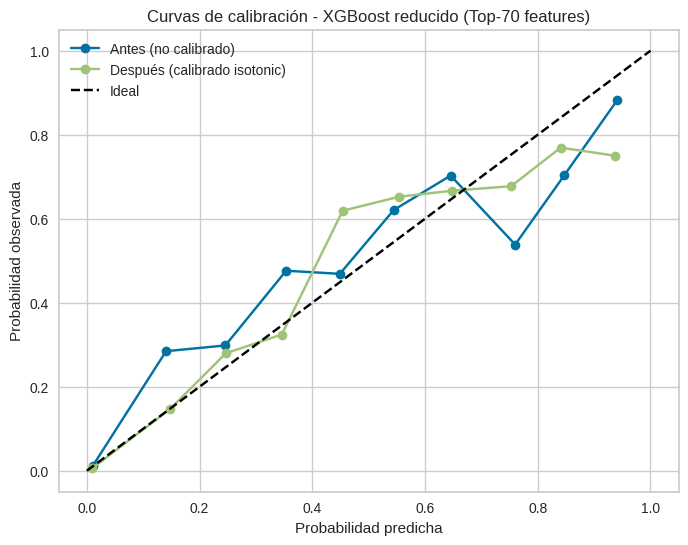

In [31]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt


y_prob_base = xgb_reduced.predict_proba(X_test_sel)[:, 1]

brier_before = brier_score_loss(y_test, y_prob_base)
print("Brier Score (antes de calibración):", brier_before)

#calibración (Isotonic)
calibrated_clf = CalibratedClassifierCV(xgb_reduced, method="isotonic", cv=5)
calibrated_clf.fit(X_train_sel, y_train)

# Predicciones calibradas
y_prob_cal = calibrated_clf.predict_proba(X_test_sel)[:, 1]

brier_after = brier_score_loss(y_test, y_prob_cal)
print("Brier Score (después de calibración):", brier_after)

# calibración
plt.figure(figsize=(8,6))


prob_true_base, prob_pred_base = calibration_curve(y_test, y_prob_base, n_bins=10)
plt.plot(prob_pred_base, prob_true_base, marker="o", label="Antes (no calibrado)")


prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Después (calibrado isotonic)")


plt.plot([0,1],[0,1], linestyle="--", color="black", label="Ideal")

plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad observada")
plt.title("Curvas de calibración - XGBoost reducido con top-70 features")
plt.legend()
plt.show()

El Brier Score disminuyó tras la calibración, lo que indica una mejor correspondencia entre las probabilidades predichas y las probabilidades observadas. Si bien la diferencia es pequeña, confirma que el ajuste aportó una mayor fidelidad probabilística.

En la gráfica se aprecia lo siguiente:

- La línea negra punteada representa la calibración ideal, donde las probabilidades predichas coinciden perfectamente con las observadas.

- El modelo sin calibrar (azul) tiende a sobreestimar en algunos tramos (ej. entre 0.6 y 0.9) y a subestimar en la zona de 0.3 a 0.5.

- Tras aplicar calibración isotónica (verde), la curva se alinea mejor con la diagonal ideal, especialmente en el rango intermedio de probabilidades (0.3, 0.7) reduciendo el sesgo en la estimación.

La calibración mejoró la calidad de las probabilidades entregadas por el modelo, tanto de forma cuantitativa (menor Brier Score) como visual (curva más cercana a la ideal). Esto significa que las predicciones son ahora más confiables para la toma de decisiones:

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>